# Đánh giá ALS Recommendation trên Google Colab

Notebook này dùng để đánh giá mô hình **ALS Collaborative Filtering** của dự án Steam Hybrid Recommendation.

Các nhóm chỉ số chính:

- Precision@10, Precision@30
- Recall@10, Recall@30
- HitRate@10, HitRate@30
- NDCG@10, NDCG@30
- Catalog Coverage
- Popularity Bias
- Phân tích phân phối ALS score
- Phân tích số lượng game được recommend

Notebook này giả định bạn đã có các bảng BigQuery:

- `steam_gold.gold_recommendations_top30_10000users_demo`
- `steam_gold.gold_als_interaction_split`
- `steam_gold.gold_game_profile_features`

Nếu schema bảng của bạn hơi khác, hãy chỉnh phần cấu hình cột ở mục **3. Cấu hình bảng và cột**.

In [1]:
# 1. Cài thư viện cần thiết
!pip install google-cloud-bigquery pandas-gbq matplotlib -q

In [2]:
# 2. Đăng nhập Google Cloud trong Colab
from google.colab import auth
auth.authenticate_user()

print("Đã xác thực Google Cloud thành công.")

Đã xác thực Google Cloud thành công.


In [3]:
# 3. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Import thư viện thành công.")

Import thư viện thành công.


In [4]:
# 4. Cấu hình project, dataset và tên bảng

PROJECT_ID = "project-79499e5c-69d7-42b8-864"
DATASET = "steam_gold"

REC_TABLE = f"`{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo`"
SPLIT_TABLE = f"`{PROJECT_ID}.{DATASET}.gold_als_interaction_split`"
GAME_TABLE = f"`{PROJECT_ID}.{DATASET}.gold_game_profile_features`"

client = bigquery.Client(project=PROJECT_ID)

print("REC_TABLE:", REC_TABLE)
print("SPLIT_TABLE:", SPLIT_TABLE)
print("GAME_TABLE:", GAME_TABLE)

REC_TABLE: `project-79499e5c-69d7-42b8-864.steam_gold.gold_als_recommendations_top30_10000users_demo`
SPLIT_TABLE: `project-79499e5c-69d7-42b8-864.steam_gold.gold_als_interaction_split`
GAME_TABLE: `project-79499e5c-69d7-42b8-864.steam_gold.gold_game_profile_features`


In [5]:
# 5. Hàm chạy query BigQuery

def run_query(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

print("Sẵn sàng chạy BigQuery.")

Sẵn sàng chạy BigQuery.


## 1. Kiểm tra schema bảng

Chạy các cell dưới đây để xem tên cột thực tế.  
Nếu tên cột khác cấu hình mặc định, hãy sửa lại ở cell cấu hình tiếp theo.

In [6]:
# 6. Xem schema bảng recommendation ALS
sql = f"""
SELECT
  column_name,
  data_type
FROM `{PROJECT_ID}.{DATASET}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'gold_als_recommendations_top30_10000users_demo'
ORDER BY ordinal_position
"""

rec_schema = run_query(sql)
rec_schema

,column_name,data_type
0,user_id,STRING
1,app_id,INT64
2,user_idx,INT64
3,app_idx,INT64
4,als_raw_score,FLOAT64
5,als_score,FLOAT64
6,als_rank,INT64
7,trained_at,TIMESTAMP


In [7]:
# 7. Xem schema bảng split interaction
sql = f'''
SELECT
  column_name,
  data_type
FROM `{PROJECT_ID}.{DATASET}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'gold_als_interaction_split'
ORDER BY ordinal_position
'''
split_schema = run_query(sql)
split_schema

,column_name,data_type
0,user_idx,INT64
1,app_idx,INT64
2,user_id,STRING
3,app_id,INT64
4,interaction_score,FLOAT64
5,review_count_for_pair,INT64
6,positive_review_count,INT64
7,negative_review_count,INT64
8,unknown_vote_count,INT64
9,user_game_count,INT64


In [8]:
# 8. Xem vài dòng recommendation ALS
sql = f'''
SELECT *
FROM {REC_TABLE}
LIMIT 10
'''
run_query(sql)

,user_id,app_id,user_idx,app_idx,als_raw_score,als_score,als_rank,trained_at
0,76561198011044287,220,819509,13,0.957274,1.0,1,2026-05-09 16:51:56.347633+00:00
1,76561198813158121,220,7046328,13,0.796077,1.0,1,2026-05-09 16:51:56.347633+00:00
2,76561198079012451,220,2523067,13,0.498892,1.0,1,2026-05-09 16:51:56.347633+00:00
3,76561198009884241,220,794097,13,0.640559,1.0,1,2026-05-09 16:51:56.347633+00:00
4,76561198042846211,220,1545441,13,0.594978,1.0,1,2026-05-09 16:51:56.347633+00:00
5,76561198084871573,220,2675968,13,0.671096,1.0,1,2026-05-09 16:51:56.347633+00:00
6,76561198082713718,220,2622914,13,0.932208,1.0,1,2026-05-09 16:51:56.347633+00:00
7,76561198021877026,220,1037910,13,0.518274,1.0,1,2026-05-09 16:51:56.347633+00:00
8,76561198162538602,220,4198677,13,0.881423,1.0,1,2026-05-09 16:51:56.347633+00:00
9,76561198084213372,220,2659989,13,0.951756,1.0,1,2026-05-09 16:51:56.347633+00:00


In [9]:
# 9. Xem vài dòng interaction split
sql = f'''
SELECT *
FROM {SPLIT_TABLE}
LIMIT 10
'''
run_query(sql)

,user_idx,app_idx,user_id,app_id,interaction_score,review_count_for_pair,positive_review_count,negative_review_count,unknown_vote_count,user_game_count,game_user_count,split_type,gold_processed_at
0,4317012,1,76561198170739399,10,2.588155,1,1,0,0,3,92079,train,2026-05-09 15:19:42.851501+00:00
1,5329436,1,76561198281546855,10,2.006514,1,1,0,0,102,92079,test,2026-05-09 15:19:42.851501+00:00
2,343782,1,76561197986265606,10,3.226307,1,1,0,0,4,92079,train,2026-05-09 15:19:42.851501+00:00
3,3766598,1,76561198137711681,10,2.959026,1,1,0,0,2,92079,train,2026-05-09 15:19:42.851501+00:00
4,1626137,1,76561198045187856,10,2.366057,1,1,0,0,18,92079,train,2026-05-09 15:19:42.851501+00:00
5,7287129,1,76561198844780152,10,2.579706,1,1,0,0,2,92079,train,2026-05-09 15:19:42.851501+00:00
6,8513215,1,76561199055299496,10,2.954240,1,1,0,0,2,92079,train,2026-05-09 15:19:42.851501+00:00
7,2106621,1,76561198063502902,10,2.516680,1,1,0,0,44,92079,train,2026-05-09 15:19:42.851501+00:00
8,3546050,1,76561198126036334,10,1.997769,1,1,0,0,9,92079,train,2026-05-09 15:19:42.851501+00:00
9,4318531,1,76561198170869053,10,2.586409,1,1,0,0,4,92079,train,2026-05-09 15:19:42.851501+00:00


## 2. Cấu hình cột đánh giá

Bạn cần chỉnh các biến dưới đây đúng với schema thật.

Thông thường bảng recommendation có:

- `user_id`
- `app_id`
- `rank`
- `als_score`

Bảng split có thể có:

- `user_id`
- `app_id`
- `split`
- `label` hoặc `rating`

Nếu bảng split của bạn dùng `is_test`, `dataset_split`, `recommended`, `rating`, hãy sửa `TEST_FILTER`.

In [10]:
# 10. Cấu hình tên cột

# Bảng recommendation
REC_USER_COL = "user_id"
REC_ITEM_COL = "app_id"
REC_RANK_COL = "rank"          # nếu bảng bạn dùng item_rank thì sửa thành "item_rank"
REC_SCORE_COL = "als_score"    # nếu bảng bạn dùng score thì sửa thành "score"

# Bảng split interaction
SPLIT_USER_COL = "user_id"
SPLIT_ITEM_COL = "app_id"

# Điều kiện lấy test positives.
# Hãy chỉnh dòng này sau khi xem schema bảng gold_als_interaction_split.
# Một số ví dụ:
# TEST_FILTER = "split = 'test' AND label = 1"
# TEST_FILTER = "dataset_split = 'test' AND label = 1"
# TEST_FILTER = "split = 'test' AND rating >= 0.5"
# TEST_FILTER = "is_test = TRUE AND label = 1"

TEST_FILTER = "split = 'test' AND label = 1"

print("Cấu hình hiện tại:")
print("Recommendation:", REC_USER_COL, REC_ITEM_COL, REC_RANK_COL, REC_SCORE_COL)
print("Split:", SPLIT_USER_COL, SPLIT_ITEM_COL)
print("TEST_FILTER:", TEST_FILTER)

Cấu hình hiện tại:
Recommendation: user_id app_id rank als_score
Split: user_id app_id
TEST_FILTER: split = 'test' AND label = 1


## 3. Kiểm tra tổng quan dữ liệu ALS

Phần này kiểm tra:

- Số dòng recommendation
- Số user được recommend
- Số game khác nhau được recommend
- Rank min/max
- ALS score min/max/avg

In [14]:
# 11. Kiểm tra tổng quan ALS output

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"

REC_USER_COL = "user_id"
REC_ITEM_COL = "app_id"
REC_RANK_COL = "als_rank"
REC_SCORE_COL = "als_score"

sql = f"""
SELECT
  COUNT(*) AS total_rows,
  COUNT(DISTINCT `{REC_USER_COL}`) AS user_count,
  COUNT(DISTINCT `{REC_ITEM_COL}`) AS recommended_game_count,
  MIN(`{REC_RANK_COL}`) AS min_rank,
  MAX(`{REC_RANK_COL}`) AS max_rank,
  AVG(`{REC_SCORE_COL}`) AS avg_als_score,
  MIN(`{REC_SCORE_COL}`) AS min_als_score,
  MAX(`{REC_SCORE_COL}`) AS max_als_score
FROM `{REC_TABLE}`
"""

als_summary = run_query(sql)
als_summary

,total_rows,user_count,recommended_game_count,min_rank,max_rank,avg_als_score,min_als_score,max_als_score
0,300000,10000,632,1,30,0.5,0.0,1.0


## 4. Đánh giá Ranking Metrics

Các chỉ số:

### Precision@K

Trong Top-K game hệ thống đề xuất, có bao nhiêu game thật sự nằm trong test positives.

```text
Precision@K = hits@K / K
```

### Recall@K

Trong toàn bộ game user thật sự thích ở test set, hệ thống tìm lại được bao nhiêu game.

```text
Recall@K = hits@K / số test positives của user
```

### HitRate@K

User có ít nhất một hit trong Top-K hay không.

```text
HitRate@K = số user có hits@K > 0 / tổng số user test
```

### NDCG@K

Đánh giá chất lượng xếp hạng. Hit ở rank cao được thưởng nhiều hơn hit ở rank thấp.

In [17]:
# 13. Hàm tính ranking metrics bằng BigQuery

import pandas as pd

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"
SPLIT_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_interaction_split"

REC_USER_COL = "user_id"
REC_ITEM_COL = "app_id"
REC_RANK_COL = "als_rank"
REC_SCORE_COL = "als_score"

SPLIT_USER_COL = "user_id"
SPLIT_ITEM_COL = "app_id"

# Nếu muốn đánh giá đúng recommendation positive
TEST_FILTER = """
split_type = 'test'
AND interaction_score > 0
"""

def evaluate_ranking_metrics(k: int) -> pd.DataFrame:
    sql = f"""
    WITH rec AS (
      SELECT
        CAST(`{REC_USER_COL}` AS STRING) AS user_id,
        CAST(`{REC_ITEM_COL}` AS STRING) AS app_id,
        CAST(`{REC_RANK_COL}` AS INT64) AS rank_position,
        CAST(`{REC_SCORE_COL}` AS FLOAT64) AS als_score
      FROM `{REC_TABLE}`
      WHERE CAST(`{REC_RANK_COL}` AS INT64) <= {k}
    ),

    test_pos AS (
      SELECT DISTINCT
        CAST(`{SPLIT_USER_COL}` AS STRING) AS user_id,
        CAST(`{SPLIT_ITEM_COL}` AS STRING) AS app_id
      FROM `{SPLIT_TABLE}`
      WHERE {TEST_FILTER}
    ),

    test_user_count AS (
      SELECT
        user_id,
        COUNT(DISTINCT app_id) AS test_positive_count
      FROM test_pos
      GROUP BY user_id
    ),

    joined AS (
      SELECT
        r.user_id,
        r.app_id,
        r.rank_position,
        IF(t.app_id IS NOT NULL, 1, 0) AS is_hit
      FROM rec r
      LEFT JOIN test_pos t
        ON r.user_id = t.user_id
       AND r.app_id = t.app_id
    ),

    per_user_hits AS (
      SELECT
        u.user_id,
        IFNULL(SUM(j.is_hit), 0) AS hits_at_k,
        COUNT(j.app_id) AS recommended_count,
        u.test_positive_count,

        IFNULL(
          SUM(
            CASE
              WHEN j.is_hit = 1
              THEN 1.0 / (LOG(j.rank_position + 1) / LOG(2))
              ELSE 0.0
            END
          ),
          0.0
        ) AS dcg_at_k
      FROM test_user_count u
      LEFT JOIN joined j
        ON u.user_id = j.user_id
      GROUP BY
        u.user_id,
        u.test_positive_count
    ),

    idcg AS (
      SELECT
        user_id,
        SUM(1.0 / (LOG(pos + 1) / LOG(2))) AS idcg_at_k
      FROM test_user_count,
      UNNEST(GENERATE_ARRAY(1, LEAST({k}, test_positive_count))) AS pos
      GROUP BY user_id
    ),

    per_user_metrics AS (
      SELECT
        p.user_id,
        p.hits_at_k,
        p.recommended_count,
        p.test_positive_count,

        SAFE_DIVIDE(p.hits_at_k, {k}) AS precision_at_k,
        SAFE_DIVIDE(p.hits_at_k, p.test_positive_count) AS recall_at_k,
        IF(p.hits_at_k > 0, 1.0, 0.0) AS hitrate_at_k,
        SAFE_DIVIDE(p.dcg_at_k, i.idcg_at_k) AS ndcg_at_k
      FROM per_user_hits p
      LEFT JOIN idcg i
        ON p.user_id = i.user_id
    )

    SELECT
      {k} AS k,
      COUNT(*) AS evaluated_users,
      AVG(precision_at_k) AS precision_at_k,
      AVG(recall_at_k) AS recall_at_k,
      AVG(hitrate_at_k) AS hitrate_at_k,
      AVG(ndcg_at_k) AS ndcg_at_k,
      AVG(hits_at_k) AS avg_hits_at_k,
      AVG(test_positive_count) AS avg_test_positives_per_user
    FROM per_user_metrics
    """

    return run_query(sql)


metrics_10 = evaluate_ranking_metrics(10)
metrics_30 = evaluate_ranking_metrics(30)

ranking_metrics = pd.concat([metrics_10, metrics_30], ignore_index=True)
ranking_metrics

,k,evaluated_users,precision_at_k,recall_at_k,hitrate_at_k,ndcg_at_k,avg_hits_at_k,avg_test_positives_per_user
0,10,3054300,0.000276,0.000083,0.001819,0.000284,0.002757,2.068218
1,30,3054300,0.000232,0.000207,0.002694,0.000260,0.006958,2.068218


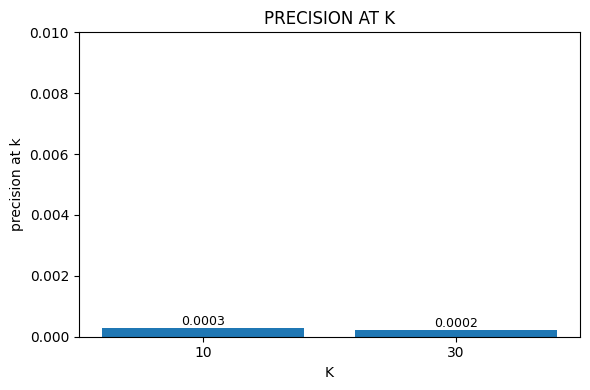

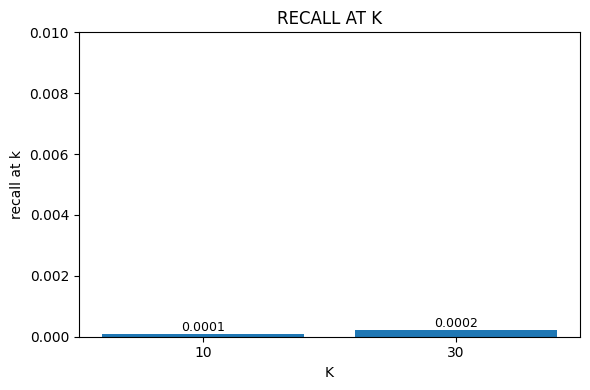

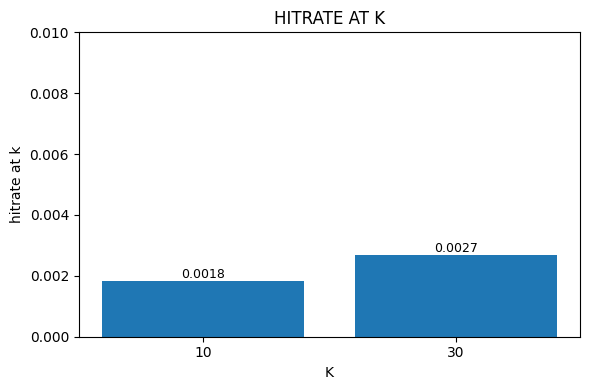

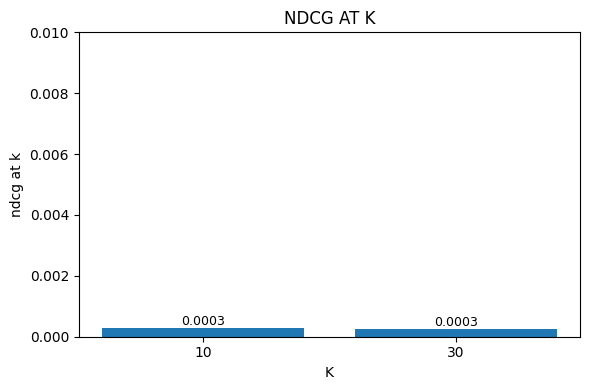

In [18]:
# 14. Vẽ biểu đồ ranking metrics

import matplotlib.pyplot as plt
import numpy as np

plot_df = ranking_metrics.copy()

metrics_to_plot = [
    "precision_at_k",
    "recall_at_k",
    "hitrate_at_k",
    "ndcg_at_k"
]

# Đảm bảo dữ liệu không bị NaN
plot_df[metrics_to_plot] = plot_df[metrics_to_plot].fillna(0)

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))

    x = plot_df["k"].astype(str)
    y = plot_df[metric]

    bars = plt.bar(x, y)

    plt.title(metric.replace("_", " ").upper())
    plt.xlabel("K")
    plt.ylabel(metric.replace("_", " "))

    ymax = max(float(y.max()) * 1.25, 0.01)
    plt.ylim(0, ymax)

    # Hiển thị giá trị trên đầu cột
    for bar, value in zip(bars, y):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

## 5. Catalog Coverage

Catalog Coverage đo hệ thống đã recommend được bao nhiêu phần trăm catalog.

```text
CatalogCoverage = số game khác nhau được recommend / tổng số game trong catalog
```

Chỉ số này rất quan trọng vì ALS thường có xu hướng tập trung vào một nhóm game phổ biến.

In [19]:
# 15. Catalog coverage của ALS

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"
GAME_TABLE = f"{PROJECT_ID}.{DATASET}.gold_game_profile_features"

REC_ITEM_COL = "app_id"

sql = f"""
WITH rec_games AS (
  SELECT DISTINCT
    CAST(`{REC_ITEM_COL}` AS STRING) AS app_id
  FROM `{REC_TABLE}`
),

catalog AS (
  SELECT DISTINCT
    CAST(app_id AS STRING) AS app_id
  FROM `{GAME_TABLE}`
  WHERE app_id IS NOT NULL
)

SELECT
  (SELECT COUNT(*) FROM rec_games) AS recommended_unique_games,
  (SELECT COUNT(*) FROM catalog) AS catalog_games,
  SAFE_DIVIDE(
    (SELECT COUNT(*) FROM rec_games),
    (SELECT COUNT(*) FROM catalog)
  ) AS catalog_coverage
"""

catalog_coverage = run_query(sql)
catalog_coverage

,recommended_unique_games,catalog_games,catalog_coverage
0,632,50872,0.012423


## 6. Popularity Bias

Phần này kiểm tra ALS có bị tập trung vào game phổ biến hay không.

Nếu các game được recommend có `popularity_score` trung bình cao hơn nhiều so với catalog, điều đó cho thấy mô hình có thiên lệch về game phổ biến.

In [20]:
# 16. So sánh popularity_score giữa game được recommend và toàn bộ catalog

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"
GAME_TABLE = f"{PROJECT_ID}.{DATASET}.gold_game_profile_features"

REC_ITEM_COL = "app_id"

sql = f"""
WITH rec_games AS (
  SELECT DISTINCT
    CAST(`{REC_ITEM_COL}` AS STRING) AS app_id
  FROM `{REC_TABLE}`
),

catalog AS (
  SELECT
    CAST(app_id AS STRING) AS app_id,
    popularity_score,
    quality_score,
    recency_score,
    price_attractiveness_score
  FROM `{GAME_TABLE}`
  WHERE app_id IS NOT NULL
)

SELECT
  'recommended_games' AS group_name,
  COUNT(*) AS game_count,
  AVG(popularity_score) AS avg_popularity_score,
  AVG(quality_score) AS avg_quality_score,
  AVG(recency_score) AS avg_recency_score,
  AVG(price_attractiveness_score) AS avg_price_score
FROM catalog c
JOIN rec_games r
  ON c.app_id = r.app_id

UNION ALL

SELECT
  'all_catalog' AS group_name,
  COUNT(*) AS game_count,
  AVG(popularity_score) AS avg_popularity_score,
  AVG(quality_score) AS avg_quality_score,
  AVG(recency_score) AS avg_recency_score,
  AVG(price_attractiveness_score) AS avg_price_score
FROM catalog
"""

popularity_bias = run_query(sql)
popularity_bias

,group_name,game_count,avg_popularity_score,avg_quality_score,avg_recency_score,avg_price_score
0,recommended_games,620,0.059542,0.316840,0.186727,0.546306
1,all_catalog,50872,0.099740,0.269682,0.282757,0.656590


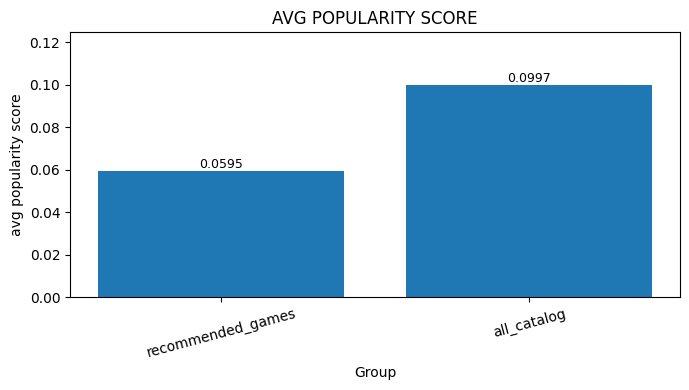

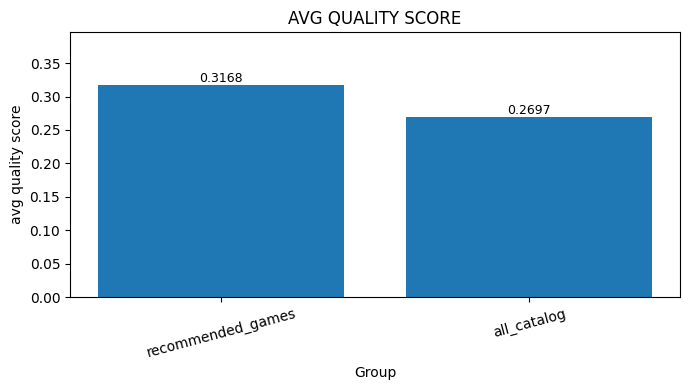

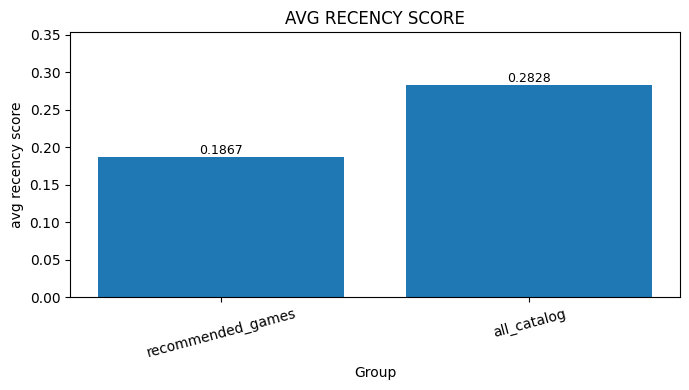

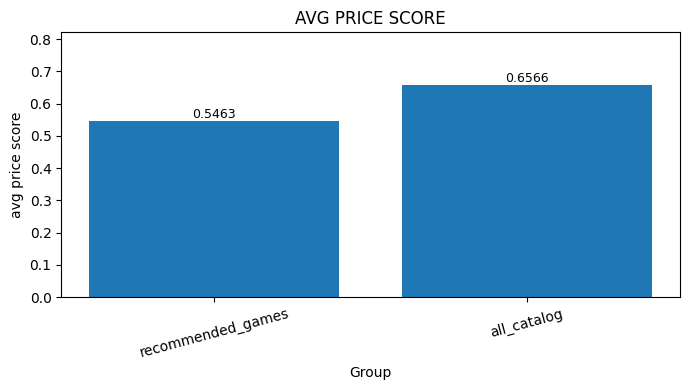

In [21]:
# 17. Vẽ biểu đồ so sánh recommended_games vs all_catalog

import matplotlib.pyplot as plt
import numpy as np

plot_df = popularity_bias.copy()

compare_cols = [
    "avg_popularity_score",
    "avg_quality_score",
    "avg_recency_score",
    "avg_price_score"
]

# Đảm bảo không bị NaN
plot_df[compare_cols] = plot_df[compare_cols].fillna(0)

for col in compare_cols:
    plt.figure(figsize=(7, 4))

    x = plot_df["group_name"]
    y = plot_df[col]

    bars = plt.bar(x, y)

    plt.title(col.replace("_", " ").upper())
    plt.xlabel("Group")
    plt.ylabel(col.replace("_", " "))

    ymax = max(float(y.max()) * 1.25, 0.01)
    plt.ylim(0, ymax)

    for bar, value in zip(bars, y):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 7. Phân phối số lần game được recommend

Phần này cho biết một số game có bị recommend quá nhiều hay không.

In [22]:
# 18. Top game được recommend nhiều nhất bởi ALS

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"
GAME_TABLE = f"{PROJECT_ID}.{DATASET}.gold_game_profile_features"

REC_ITEM_COL = "app_id"
REC_SCORE_COL = "als_score"

sql = f"""
SELECT
  r.`{REC_ITEM_COL}` AS app_id,
  ANY_VALUE(g.game_title) AS game_title,
  COUNT(*) AS recommended_count,
  COUNT(DISTINCT r.user_id) AS recommended_user_count,
  AVG(r.`{REC_SCORE_COL}`) AS avg_als_score,
  MIN(r.als_rank) AS best_rank,
  MAX(r.als_rank) AS worst_rank,
  ANY_VALUE(g.popularity_score) AS popularity_score,
  ANY_VALUE(g.quality_score) AS quality_score,
  ANY_VALUE(g.recency_score) AS recency_score,
  ANY_VALUE(g.price_attractiveness_score) AS price_score
FROM `{REC_TABLE}` r
LEFT JOIN `{GAME_TABLE}` g
  ON CAST(r.`{REC_ITEM_COL}` AS STRING) = CAST(g.app_id AS STRING)
GROUP BY app_id
ORDER BY recommended_count DESC
LIMIT 30
"""

top_rec_games = run_query(sql)
top_rec_games

,app_id,game_title,recommended_count,recommended_user_count,avg_als_score,best_rank,worst_rank,popularity_score,quality_score,recency_score,price_score
0,292030,The Witcher® 3: Wild Hunt,4285,4285,0.600644,1,30,0.050172,0.3360,0.111168,0.3750
1,550,Left 4 Dead 2,4222,4222,0.734609,1,30,0.050172,0.3395,0.100000,0.6375
2,620,Portal 2,4094,4094,0.633442,1,30,0.050172,0.3430,0.100000,0.6375
3,379720,DOOM,4017,4017,0.577314,1,30,0.050172,0.3325,0.135409,0.5250
4,105600,Terraria,3728,3728,0.610071,1,30,0.050172,0.3395,0.100000,0.6375
5,730,Counter-Strike: Global Offensive,3499,3499,0.641839,1,30,0.050172,0.3080,0.100000,0.7500
6,203160,Tomb Raider,3397,3397,0.607240,1,30,0.050172,0.3360,0.100000,0.9125
7,271590,Grand Theft Auto V,3320,3320,0.555609,1,30,1.000000,0.3010,0.109056,0.7500
8,377160,Fallout 4,3161,3161,0.507849,1,30,0.050172,0.2905,0.122356,0.5250
9,1091500,Cyberpunk 2077,3154,3154,0.596648,1,30,0.050172,0.2800,0.338481,0.2625


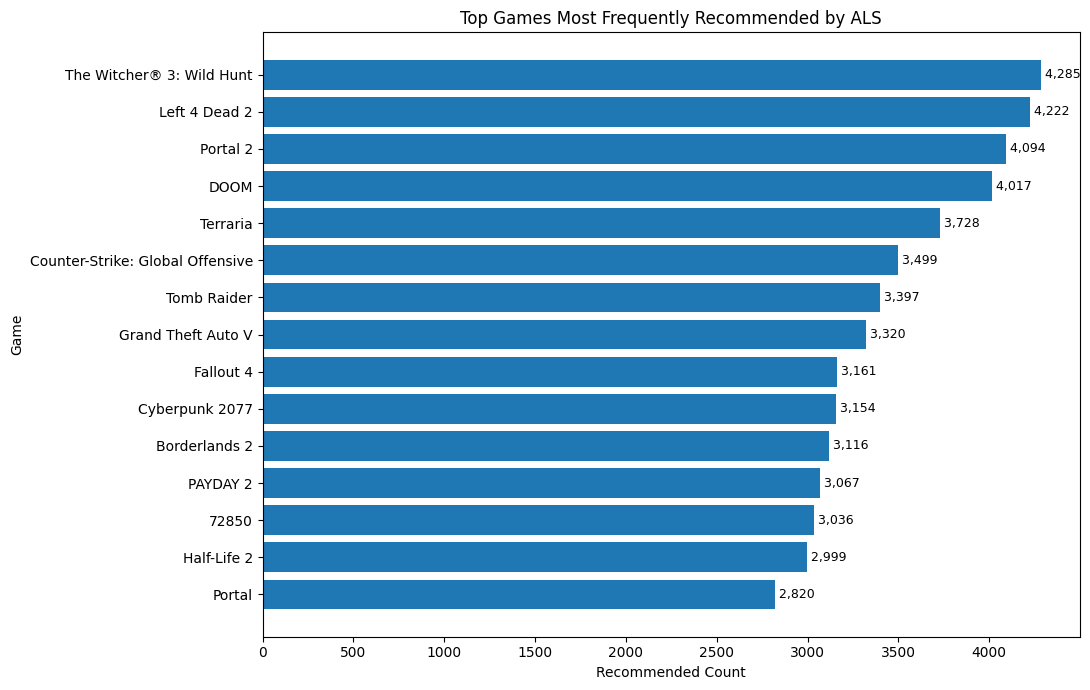

In [23]:
# 19. Biểu đồ top game được recommend nhiều nhất

import matplotlib.pyplot as plt

plot_top = top_rec_games.head(15).copy()

# Tạo label: ưu tiên game_title, nếu null thì dùng app_id
plot_top["label"] = plot_top["game_title"].fillna(plot_top["app_id"].astype(str))

# Cắt tên game quá dài để biểu đồ không bị rối
plot_top["label_short"] = plot_top["label"].apply(
    lambda x: x[:45] + "..." if len(str(x)) > 45 else str(x)
)

# Đảo thứ tự để game recommend nhiều nhất nằm trên cùng
plot_top = plot_top.iloc[::-1]

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_top["label_short"],
    plot_top["recommended_count"]
)

plt.title("Top Games Most Frequently Recommended by ALS")
plt.xlabel("Recommended Count")
plt.ylabel("Game")

# Hiển thị số ở cuối thanh
for bar, value in zip(bars, plot_top["recommended_count"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {int(value):,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 8. Phân phối ALS score

Phần này kiểm tra ALS score có nằm trong khoảng hợp lý không và có bị tập trung quá nhiều ở một vùng không.

In [25]:
# 20. Thống kê ALS score

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"
REC_SCORE_COL = "als_score"

sql = f"""
SELECT
  COUNT(*) AS total_rows,
  AVG(CAST(`{REC_SCORE_COL}` AS FLOAT64)) AS avg_score,
  STDDEV(CAST(`{REC_SCORE_COL}` AS FLOAT64)) AS std_score,
  MIN(CAST(`{REC_SCORE_COL}` AS FLOAT64)) AS min_score,
  APPROX_QUANTILES(CAST(`{REC_SCORE_COL}` AS FLOAT64), 10) AS deciles,
  MAX(CAST(`{REC_SCORE_COL}` AS FLOAT64)) AS max_score
FROM `{REC_TABLE}`
WHERE `{REC_SCORE_COL}` IS NOT NULL
"""

score_stats = run_query(sql)
score_stats

,total_rows,avg_score,std_score,min_score,deciles,max_score
0,300000,0.5,0.298464,0.0,"[0.0, 0.10344827586206896, 0.1724137931034483, 0.27586206896551724, 0.41379310344827586, 0.4827586206896552, 0.58620...",1.0


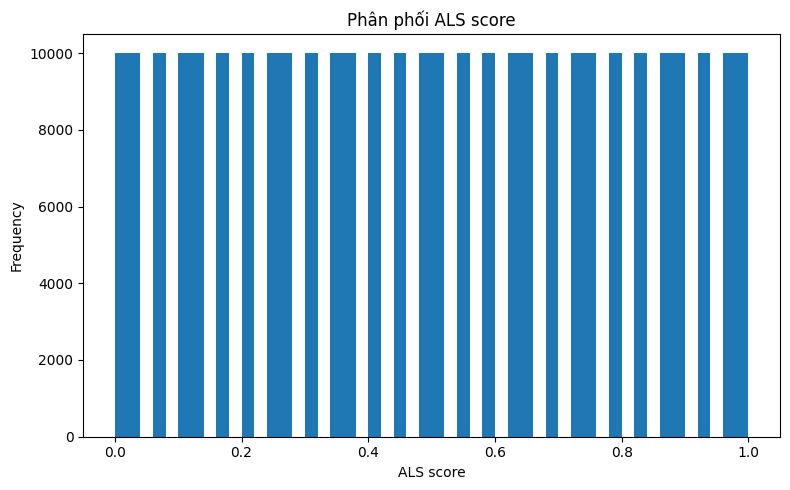

In [26]:
# 21. Lấy mẫu ALS score để vẽ histogram

import matplotlib.pyplot as plt

REC_TABLE = f"{PROJECT_ID}.{DATASET}.gold_als_recommendations_top30_10000users_demo"
REC_SCORE_COL = "als_score"

sql = f"""
SELECT
  CAST(`{REC_SCORE_COL}` AS FLOAT64) AS als_score
FROM `{REC_TABLE}`
WHERE `{REC_SCORE_COL}` IS NOT NULL
LIMIT 300000
"""

score_df = run_query(sql)

plt.figure(figsize=(8, 5))
plt.hist(score_df["als_score"].dropna(), bins=50)

plt.title("Phân phối ALS score")
plt.xlabel("ALS score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 9. Xuất bảng kết quả đánh giá ra CSV

Cell này xuất các bảng đánh giá chính ra file CSV để đưa vào báo cáo hoặc GitHub.

In [27]:
# 22. Xuất kết quả đánh giá ALS ra CSV

import os

OUTPUT_DIR = "evaluation_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ranking_metrics.to_csv(
    f"{OUTPUT_DIR}/als_ranking_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

catalog_coverage.to_csv(
    f"{OUTPUT_DIR}/als_catalog_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

popularity_bias.to_csv(
    f"{OUTPUT_DIR}/als_popularity_bias.csv",
    index=False,
    encoding="utf-8-sig"
)

top_rec_games.to_csv(
    f"{OUTPUT_DIR}/als_top_recommended_games.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã xuất các file:")
print(f"- {OUTPUT_DIR}/als_ranking_metrics.csv")
print(f"- {OUTPUT_DIR}/als_catalog_coverage.csv")
print(f"- {OUTPUT_DIR}/als_popularity_bias.csv")
print(f"- {OUTPUT_DIR}/als_top_recommended_games.csv")

Đã xuất các file:
- evaluation_outputs/als_ranking_metrics.csv
- evaluation_outputs/als_catalog_coverage.csv
- evaluation_outputs/als_popularity_bias.csv
- evaluation_outputs/als_top_recommended_games.csv
